# LOD MLP Training
**COMP 432 — Adaptive LOD Control**

Pipeline:
1. Load `training_data_labeled.csv`
2. Select and normalize features
3. Split train/validation
4. Define MLP (64 -> 32 -> 16 -> 1, Sigmoid output)
5. Train with MSE loss + Adam
6. Evaluate and plot
7. Export to ONNX for Unity Sentis

In [31]:
import sys
!{sys.executable} -m pip install torch torchvision pandas scikit-learn matplotlib joblib onnx

In [32]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib
import os



print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PyTorch version: 2.10.0+cpu
CUDA available: False
Using device: cpu


## 1. Configuration

In [33]:
# CONFIG
INPUT_FILE   = '../data/Train_Merged_labeled/training_data_labeled.csv'
MODEL_OUT    = '../models/lod_mlp.onnx'
SCALER_OUT   = '../models/feature_scaler.pkl'

FEATURE_COLS = [
    'cam_rot_y',              # 0.55 — never used before
    'screen_coverage',        # 0.54
    'visible_renderer_count', # 0.51
    'cam_pos_y',              # 0.49 — never used before
    'triangle_count',         # 0.49
    'path_progress',          # 0.48 — never used before
    'draw_call_estimate',     # 0.48
    'camera_velocity',        # 0.37
    'gpu_frame_time_ms',      # 0.36
    'cam_pos_x',              # 0.34 — never used before
    'cam_pos_z',              # 0.30 — never used before
    'fps',                    # 0.21
]

TARGET_COL   = 'target_lod_bias'

# MLP architecture (from project docs)
HIDDEN1 = 64
HIDDEN2 = 32
HIDDEN3 = 16

# Training
BATCH_SIZE        = 512
EPOCHS            = 150
LR                = 1e-3
VAL_SPLIT         = 0.2
SEED              = 42
DIVERSITY_WEIGHT  = 0.01  # penalizes mean collapse in predictions

# LOD bias range for output denormalization
BIAS_MIN = 0.25
BIAS_MAX = 2.0
#

torch.manual_seed(SEED)
np.random.seed(SEED)


## 2. Load and Inspect Data

In [34]:
# Load the local processed dataset
df = pd.read_csv(INPUT_FILE)
print(f'Loaded {len(df)} rows, {len(df.columns)} columns')

# Show Target Bias distribution
print(f'\nTarget distribution (LOD Bias):')
print(df[TARGET_COL].value_counts().sort_index())

# Show initial Feature statistics
print(f'\nFeature summary stats:')
display(df[FEATURE_COLS].describe().round(3))


Loaded 890588 rows, 28 columns

Target distribution (LOD Bias):
target_lod_bias
0.441229     1063
0.443857     5896
0.445080     2396
0.448779     9806
0.458725     6838
            ...  
1.078504     5603
1.081026      433
1.088137     1194
1.232413    12955
2.000000      314
Name: count, Length: 146, dtype: int64

Feature summary stats:


,cam_rot_y,screen_coverage,visible_renderer_count,cam_pos_y,triangle_count,path_progress,draw_call_estimate,camera_velocity,gpu_frame_time_ms,cam_pos_x,cam_pos_z,fps
count,890588.000,890588.000,890588.000,890588.000,890588.000,890588.000,890588.000,890588.000,8.905880e+05,890588.000,890588.000,890588.000
mean,107.068,0.009,9479.071,4.602,358903.313,4.665,2708.260,3.089,1.990387e+06,7.999,3.149,58.117
std,113.710,0.010,7900.341,2.424,243837.315,3.666,1976.745,2.808,1.878340e+09,24.299,28.302,61.501
min,-0.010,0.000,0.000,1.310,4325.000,0.000,11.000,0.000,1.600000e-02,-65.200,-65.270,3.000
25%,12.620,0.002,3348.000,2.480,172024.500,1.890,1108.000,0.500,4.270000e+00,-8.220,-16.620,17.130
50%,32.890,0.003,7111.000,3.930,288321.000,3.386,2196.000,3.000,6.162000e+00,10.170,8.330,25.570
75%,240.040,0.013,13284.000,6.890,482781.000,6.444,3878.000,3.001,1.104200e+01,28.180,28.330,78.860
max,359.990,0.064,32793.000,8.560,2501593.000,15.000,17753.000,8.018,1.772608e+12,64.450,67.910,576.930


balance labels

In [50]:
# round oracle labels to nearest 0.25 step first
df["target_lod_bias"] = (df["target_lod_bias"] / 0.25).round() * 0.25
df["target_lod_bias"] = df["target_lod_bias"].clip(0.25, 2.0)

# now balance — bins will be clean discrete values
df["label_bin"] = df["target_lod_bias"]
min_count = df["label_bin"].value_counts().min()
print(f"Bin counts before balancing:")
print(df["label_bin"].value_counts().sort_index())
print(f"min_count = {min_count}")

df = (
    df.groupby("label_bin", group_keys=False)
      .apply(lambda g: g.sample(n=min_count, random_state=42))
      .reset_index(drop=True)
)
df = df.drop(columns=["label_bin"], errors="ignore")
print(f"\nBalanced dataset: {len(df)} rows")
print(df["target_lod_bias"].value_counts().sort_index())

Bin counts before balancing:
label_bin
0.50    314
0.75    314
1.00    314
1.25    314
2.00    314
Name: count, dtype: int64
min_count = 314

Balanced dataset: 1570 rows
target_lod_bias
0.50    314
0.75    314
1.00    314
1.25    314
2.00    314
Name: count, dtype: int64


## 3. Preprocessing

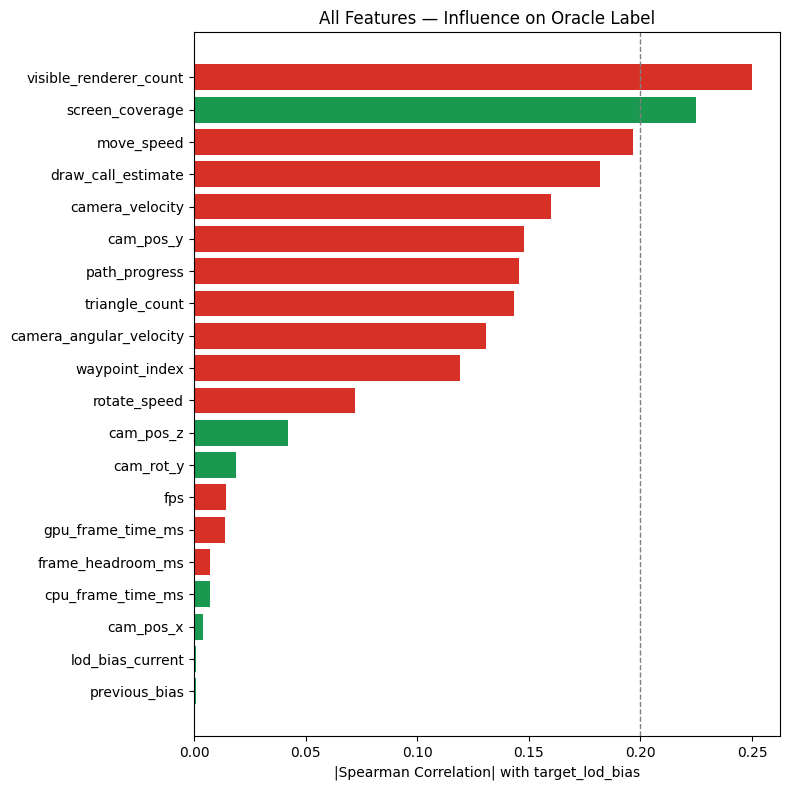

  visible_renderer_count         -0.2501  (- bias)
  screen_coverage                +0.2249  (+ bias)
  move_speed                     -0.1967  (- bias)
  draw_call_estimate             -0.1817  (- bias)
  camera_velocity                -0.1601  (- bias)
  cam_pos_y                      -0.1477  (- bias)
  path_progress                  -0.1456  (- bias)
  triangle_count                 -0.1436  (- bias)
  camera_angular_velocity        -0.1308  (- bias)
  waypoint_index                 -0.1191  (- bias)
  rotate_speed                   -0.0722  (- bias)
  cam_pos_z                      +0.0423  (+ bias)
  cam_rot_y                      +0.0187  (+ bias)
  fps                            -0.0145  (- bias)
  gpu_frame_time_ms              -0.0138  (- bias)
  cpu_frame_time_ms              +0.0072  (+ bias)
  frame_headroom_ms              -0.0072  (- bias)
  cam_pos_x                      +0.0040  (+ bias)
  previous_bias                  +0.0009  (+ bias)
  lod_bias_current             

In [35]:
FEATURE_COLS = [
    'cpu_frame_time_ms', 'gpu_frame_time_ms', 'triangle_count',
    'camera_velocity', 'camera_angular_velocity', 'visible_renderer_count',
    'draw_call_estimate', 'frame_headroom_ms', 'screen_coverage',
    'lod_bias_current', 'fps', 'previous_bias',
    'cam_pos_x', 'cam_pos_y', 'cam_pos_z', 'cam_rot_y',
    'path_progress', 'waypoint_index', 'move_speed', 'rotate_speed'
]

corr = df[FEATURE_COLS + [TARGET_COL]].corr(method='spearman')[TARGET_COL].drop(TARGET_COL)
corr_sorted = corr.abs().sort_values(ascending=True)
colors = ['#d73027' if corr[f] < 0 else '#1a9850' for f in corr_sorted.index]

plt.figure(figsize=(8, 8))
plt.barh(corr_sorted.index, corr_sorted.values, color=colors)
plt.axvline(x=0.2, color='gray', linestyle='--', linewidth=1)
plt.xlabel('|Spearman Correlation| with target_lod_bias')
plt.title('All Features — Influence on Oracle Label')
plt.tight_layout()
plt.savefig('../plots/training/feature_influence_all.png', dpi=150)
plt.show()

for f in corr.abs().sort_values(ascending=False).index:
    direction = "+ bias" if corr[f] > 0 else "- bias"
    print(f"  {f:<30} {corr[f]:+.4f}  ({direction})")

In [36]:
# Drop rows with NaN in features or target
df = df.dropna(subset=FEATURE_COLS + [TARGET_COL])
print(f'Rows after dropna: {len(df)}')

X     = df[FEATURE_COLS].values.astype(np.float32)
y_raw = df[TARGET_COL].values.astype(np.float32)

#  Label diagnostic
print(f'\nRaw target_lod_bias stats:')
print(f'  min={y_raw.min():.4f}  max={y_raw.max():.4f}  mean={y_raw.mean():.4f}  std={y_raw.std():.4f}')
print(f'  unique values: {len(np.unique(y_raw.round(4)))}')

# Normalize target to [0, 1] for Sigmoid output
y = (y_raw - BIAS_MIN) / (BIAS_MAX - BIAS_MIN)
print(f'\nNormalized target range: [{y.min():.4f}, {y.max():.4f}]')
print(f'Normalized target std:   {y.std():.4f}  (< 0.05 = collapse risk)')

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)
joblib.dump(scaler, SCALER_OUT)
assert os.path.exists(SCALER_OUT), f'Scaler not saved: {SCALER_OUT}'
print(f'Scaler saved to {SCALER_OUT}')

#  Feature variance diagnostic
print(f'\nFeature std after scaling (should all be ~1.0):')
for name, std in zip(FEATURE_COLS, X.std(axis=0)):
    flag = '  <-- LOW VARIANCE' if std < 0.5 else ''
    print(f'  {name:<30} std={std:.4f}{flag}')

# Split off 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)
# Split remaining into 80% train / 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, shuffle=True
)

print(f'\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')


Rows after dropna: 890588

Raw target_lod_bias stats:
  min=0.4412  max=2.0000  mean=0.6417  std=0.1350
  unique values: 142

Normalized target range: [0.1093, 1.0000]
Normalized target std:   0.0771  (< 0.05 = collapse risk)
Scaler saved to ../models/feature_scaler.pkl

Feature std after scaling (should all be ~1.0):
  cpu_frame_time_ms              std=1.0000
  gpu_frame_time_ms              std=1.0000
  triangle_count                 std=1.0000
  camera_velocity                std=1.0000
  camera_angular_velocity        std=1.0000
  visible_renderer_count         std=1.0000
  draw_call_estimate             std=1.0000
  frame_headroom_ms              std=1.0000
  screen_coverage                std=1.0000
  lod_bias_current               std=1.0000
  fps                            std=1.0000
  previous_bias                  std=1.0000
  cam_pos_x                      std=1.0000
  cam_pos_y                      std=1.0000
  cam_pos_z                      std=1.0000
  cam_rot_y         

## 4. Dataset and DataLoader

In [37]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t,   y_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 1114 | Val batches: 279


## 5. Model Definition
Architecture from project docs: Input -> 64 (ReLU) -> 32 (ReLU) -> 1 (Sigmoid)

In [38]:
class LODPredictor(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, hidden3=16):
        super(LODPredictor, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, hidden3),
            nn.ReLU(),
            nn.Linear(hidden3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

INPUT_DIM = X_train.shape[1]
model     = LODPredictor(INPUT_DIM, HIDDEN1, HIDDEN2, HIDDEN3).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params}')

LODPredictor(
  (layers): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Total parameters: 3969


## 6. Training

In [39]:
def diversity_loss(preds, weight=DIVERSITY_WEIGHT):
    """Penalize low batch prediction variance — prevents mean collapse."""
    pred_std = preds.std()
    if pred_std < 1e-6:
        return torch.tensor(0.0, device=preds.device)
    return -weight * pred_std

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.HuberLoss(delta=0.3)

BEST_MODEL_PATH = '../models/best_model.pt'

train_losses     = []
train_div_losses = []
val_losses       = []
best_val_loss    = float('inf')

for epoch in range(EPOCHS):
    # --- train ---
    model.train()
    batch_losses = []
    div_losses   = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)

        huber = criterion(preds, y_batch)
        div   = diversity_loss(preds)
        loss  = huber + div

        loss.backward()
        optimizer.step()
        batch_losses.append(huber.item())
        div_losses.append(abs(div.item()))

    train_loss = np.mean(batch_losses)
    train_div  = np.mean(div_losses)

    #  validate (no diversity term)
    model.eval()
    with torch.no_grad():
        val_batch_losses = []
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = model(X_batch)
            val_batch_losses.append(criterion(preds, y_batch).item())
        val_loss = np.mean(val_batch_losses)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)

    train_losses.append(train_loss)
    train_div_losses.append(train_div)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Huber: {train_loss:.6f} | Div: {train_div:.6f} | Val: {val_loss:.6f}')

print('Training complete.')

# Reload best checkpoint
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
print(f'Loaded best model (val loss: {best_val_loss:.6f})')

# --- test ---
with torch.no_grad():
    X_test_t   = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    y_test_t   = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(DEVICE)
    test_preds = model(X_test_t)
    test_loss  = criterion(test_preds, y_test_t).item()

test_preds_bias  = test_preds.detach().cpu().numpy().flatten() * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_target_bias = y_test * (BIAS_MAX - BIAS_MIN) + BIAS_MIN

test_mae  = np.mean(np.abs(test_preds_bias - test_target_bias))
test_rmse = np.sqrt(np.mean((test_preds_bias - test_target_bias) ** 2))

print(f'\nTest Huber (normalized): {test_loss:.6f}')
print(f'Test MAE   (bias units): {test_mae:.4f}')
print(f'Test RMSE  (bias units): {test_rmse:.4f}')
print(f'\nPredicted bias — min: {test_preds_bias.min():.4f}  max: {test_preds_bias.max():.4f}  std: {test_preds_bias.std():.4f}')
print(f'Oracle  bias  — min: {test_target_bias.min():.4f}  max: {test_target_bias.max():.4f}  std: {test_target_bias.std():.4f}')

Epoch  10/150 | Huber: 0.000186 | Div: 0.000848 | Val: 0.000211
Epoch  20/150 | Huber: 0.000155 | Div: 0.000853 | Val: 0.000195
Epoch  30/150 | Huber: 0.000144 | Div: 0.000855 | Val: 0.000124
Epoch  40/150 | Huber: 0.000139 | Div: 0.000855 | Val: 0.000149
Epoch  50/150 | Huber: 0.000133 | Div: 0.000856 | Val: 0.000121
Epoch  60/150 | Huber: 0.000128 | Div: 0.000856 | Val: 0.000120
Epoch  70/150 | Huber: 0.000122 | Div: 0.000857 | Val: 0.000148
Epoch  80/150 | Huber: 0.000121 | Div: 0.000857 | Val: 0.000123
Epoch  90/150 | Huber: 0.000121 | Div: 0.000858 | Val: 0.000112
Epoch 100/150 | Huber: 0.000115 | Div: 0.000858 | Val: 0.000117
Epoch 110/150 | Huber: 0.000116 | Div: 0.000858 | Val: 0.000118
Epoch 120/150 | Huber: 0.000114 | Div: 0.000858 | Val: 0.000118
Epoch 130/150 | Huber: 0.000111 | Div: 0.000859 | Val: 0.000119
Epoch 140/150 | Huber: 0.000110 | Div: 0.000859 | Val: 0.000111
Epoch 150/150 | Huber: 0.000107 | Div: 0.000859 | Val: 0.000113
Training complete.
Loaded best model (va

## 7. Loss Curves

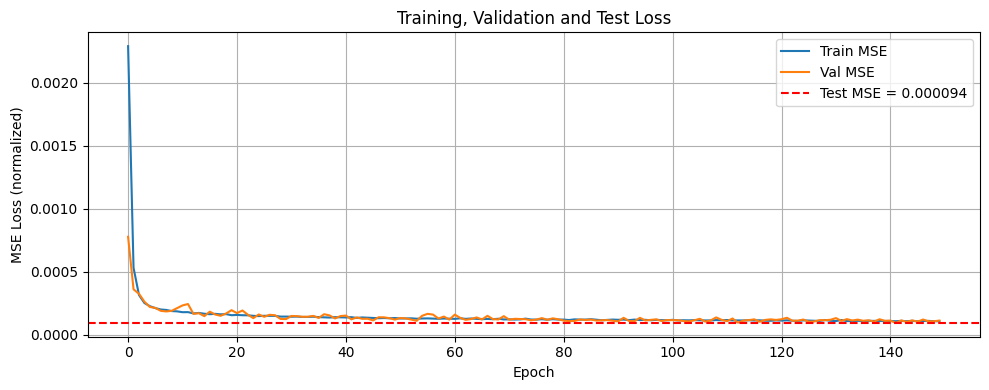

Final Train MSE : 0.000107
Final Val   MSE : 0.000113
Test        MSE : 0.000094
Test        MAE : 0.0131 (bias units)
Test        RMSE: 0.0240 (bias units)


In [40]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Val MSE')
plt.axhline(y=test_loss, color='red', linestyle='--', label=f'Test MSE = {test_loss:.6f}')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Training, Validation and Test Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../plots/training/loss_curve.png', dpi=150)
plt.show()

print(f'Final Train MSE : {train_losses[-1]:.6f}')
print(f'Final Val   MSE : {val_losses[-1]:.6f}')
print(f'Test        MSE : {test_loss:.6f}')
print(f'Test        MAE : {test_mae:.4f} (bias units)')
print(f'Test        RMSE: {test_rmse:.4f} (bias units)')

## 8. Evaluation — Denormalized Predictions



Val  MAE: 0.0131 | Val  RMSE: 0.0241
Test MAE: 0.0131 | Test RMSE: 0.0240


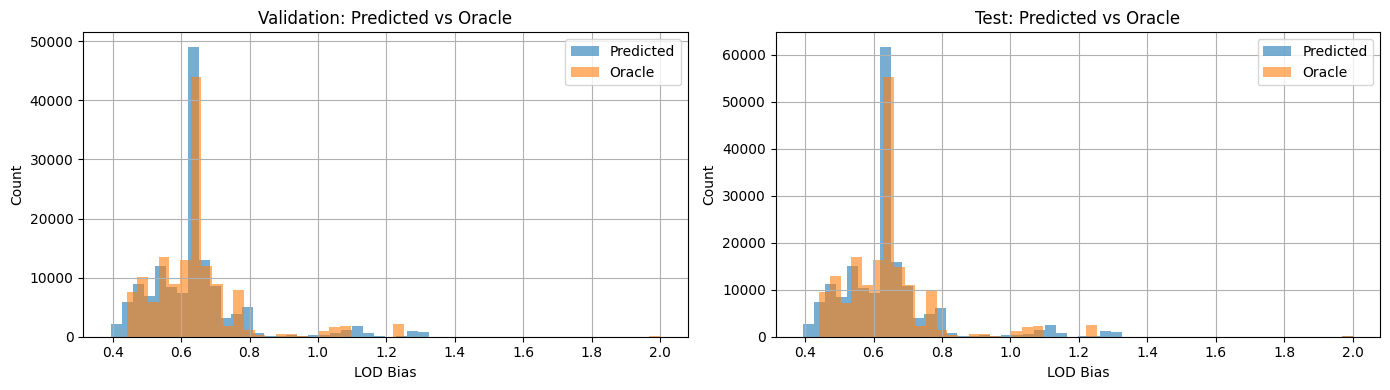

In [ ]:
model.eval()
with torch.no_grad():
    preds_norm      = model(X_val_t.to(DEVICE)).cpu().numpy().flatten()
    test_preds_norm = model(torch.tensor(X_test, dtype=torch.float32).to(DEVICE)).cpu().numpy().flatten()

# Denormalize
preds_bias       = preds_norm      * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_preds_bias  = test_preds_norm * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
target_bias      = y_val           * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_target_bias = y_test          * (BIAS_MAX - BIAS_MIN) + BIAS_MIN

# Metrics
val_mae  = np.mean(np.abs(preds_bias  - target_bias))
val_rmse = np.sqrt(np.mean((preds_bias  - target_bias) ** 2))
t_mae    = np.mean(np.abs(test_preds_bias - test_target_bias))
t_rmse   = np.sqrt(np.mean((test_preds_bias - test_target_bias) ** 2))

print(f'Val  MAE: {val_mae:.4f} | Val  RMSE: {val_rmse:.4f}')
print(f'Test MAE: {t_mae:.4f} | Test RMSE: {t_rmse:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(preds_bias,  bins=50, alpha=0.6, label='Predicted')
axes[0].hist(target_bias, bins=50, alpha=0.6, label='Oracle')
axes[0].set_title('Validation: Predicted vs Oracle')
axes[0].set_xlabel('LOD Bias')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True)

axes[1].hist(test_preds_bias,  bins=50, alpha=0.6, label='Predicted')
axes[1].hist(test_target_bias, bins=50, alpha=0.6, label='Oracle')
axes[1].set_title('Test: Predicted vs Oracle')
axes[1].set_xlabel('LOD Bias')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../plots/training/prediction_distribution.png', dpi=150)
plt.show()


checks which input features the trained model depends on. It shuffles one feature at a time and runs inference again. If the model’s loss increases, that feature is important; if not, it has little impact.

Baseline test loss: 0.000094

Permutation Importance (loss increase when feature is shuffled):
  path_progress                  +0.021995
  waypoint_index                 +0.012118
  cam_pos_y                      +0.008133
  cam_pos_x                      +0.006929
  visible_renderer_count         +0.003801
  cam_pos_z                      +0.003298
  screen_coverage                +0.002543
  cam_rot_y                      +0.002527
  camera_velocity                +0.000798
  move_speed                     +0.000767
  camera_angular_velocity        +0.000421
  cpu_frame_time_ms              +0.000350
  lod_bias_current               +0.000336
  previous_bias                  +0.000309
  frame_headroom_ms              +0.000271
  rotate_speed                   +0.000263
  draw_call_estimate             +0.000143
  triangle_count                 +0.000089  <-- USELESS
  fps                            +0.000006  <-- USELESS
  gpu_frame_time_ms              +0.000000  <-- USELESS


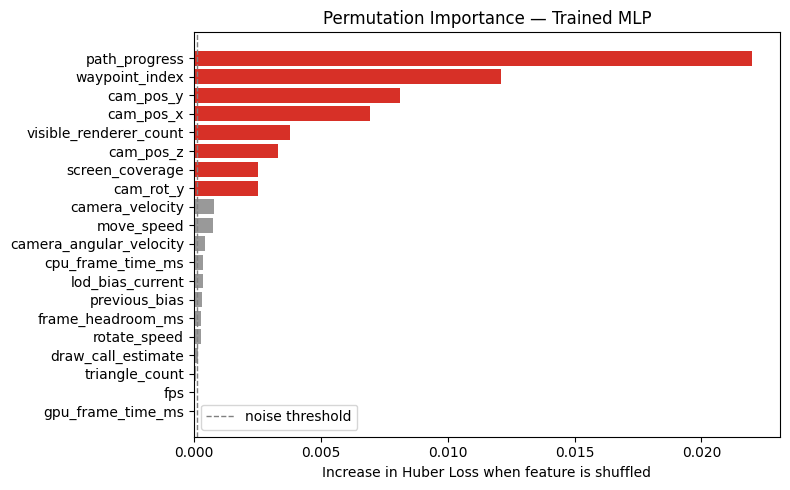

In [42]:
# Permutation Importance   which features actually matter to the trained model
import numpy as np
import matplotlib.pyplot as plt

model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(DEVICE)

with torch.no_grad():
    baseline_loss = criterion(model(X_test_t), y_test_t).item()

importance = {}
for i, name in enumerate(FEATURE_COLS):
    X_perm = X_test.copy()
    np.random.shuffle(X_perm[:, i])        # shuffle one column, leave rest intact
    X_perm_t = torch.tensor(X_perm, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        perm_loss = criterion(model(X_perm_t), y_test_t).item()
    importance[name] = perm_loss - baseline_loss  # higher = more important

importance_sorted = dict(sorted(importance.items(), key=lambda x: x[1]))

print(f"Baseline test loss: {baseline_loss:.6f}")
print(f"\nPermutation Importance (loss increase when feature is shuffled):")
for name, delta in sorted(importance.items(), key=lambda x: x[1], reverse=True):
    flag = "  <-- USELESS" if delta < 0.0001 else ""
    print(f"  {name:<30} +{delta:.6f}{flag}")

# Plot
colors = ['#d73027' if v > 0.001 else '#999999' for v in importance_sorted.values()]
plt.figure(figsize=(8, 5))
plt.barh(list(importance_sorted.keys()), list(importance_sorted.values()), color=colors)
plt.axvline(x=0.0001, color='gray', linestyle='--', linewidth=1, label='noise threshold')
plt.xlabel('Increase in Huber Loss when feature is shuffled')
plt.title('Permutation Importance — Trained MLP')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/training/permutation_importance.png', dpi=150)
plt.show()

Determines if one of the features is not needed and should be removed all together

In [43]:
# recommend features to drop based on permutation importance
noise_threshold = 0.0001

drop_list = [name for name, delta in importance.items() if delta < noise_threshold]
keep_list = [name for name, delta in importance.items() if delta >= noise_threshold]

print("\n" + "="*50)
print("FEATURE DROP RECOMMENDATION")
print("="*50)

if drop_list:
    print(f"\n  DROP these features from training AND inference ({len(drop_list)}):")
    for name in sorted(drop_list, key=lambda x: importance[x]):
        print(f"    - {name:<30} delta={importance[name]:.6f}  below noise floor")
else:
    print("\n  No features below noise threshold. Keep all.")

print(f"\n  KEEP these features ({len(keep_list)}):")
for name in sorted(keep_list, key=lambda x: importance[x], reverse=True):
    print(f"    + {name:<30} delta={importance[name]:.6f}")

print(f"\n  Feature count: {len(FEATURE_COLS)} --> {len(keep_list)} after dropping")
print("="*50)


FEATURE DROP RECOMMENDATION

  DROP these features from training AND inference (3):
    - gpu_frame_time_ms              delta=0.000000  below noise floor
    - fps                            delta=0.000006  below noise floor
    - triangle_count                 delta=0.000089  below noise floor

  KEEP these features (17):
    + path_progress                  delta=0.021995
    + waypoint_index                 delta=0.012118
    + cam_pos_y                      delta=0.008133
    + cam_pos_x                      delta=0.006929
    + visible_renderer_count         delta=0.003801
    + cam_pos_z                      delta=0.003298
    + screen_coverage                delta=0.002543
    + cam_rot_y                      delta=0.002527
    + camera_velocity                delta=0.000798
    + move_speed                     delta=0.000767
    + camera_angular_velocity        delta=0.000421
    + cpu_frame_time_ms              delta=0.000350
    + lod_bias_current               delta=0.0003

## 9. Export to ONNX for Unity Sentis

In [44]:
#!pip install onnxscript onnx
%pip install torch torchvision pandas scikit-learn matplotlib joblib onnx
%pip install onnxscript

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [45]:
model.eval()
model.cpu()

dummy_input = torch.zeros(1, INPUT_DIM, dtype=torch.float32)

torch.onnx.export(
    model,
    dummy_input,
    MODEL_OUT,
    export_params=True,
    opset_version=15,
    input_names=['features'],
    output_names=['lod_bias_normalized'],
    dynamic_axes={
        'features':           {0: 'batch_size'},
        'lod_bias_normalized': {0: 'batch_size'}
    }
)

size_kb = os.path.getsize(MODEL_OUT) / 1024
print(f'ONNX model saved to {MODEL_OUT} ({size_kb:.1f} KB)')
print(f'Input dim: {INPUT_DIM} features')
print(f'Output: normalized bias in [0,1] -> denormalize with BIAS_MIN={BIAS_MIN}, BIAS_MAX={BIAS_MAX}')

C:\Users\Gica\AppData\Local\Temp\ipykernel_16980\438338614.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0324 20:14:12.263000 16980 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 15 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `LODPredictor([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LODPredictor([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


C:\Users\Gica\AppData\Roaming\uv\python\cpython-3.12.13-windows-x86_64-none\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 15).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX model saved to ../models/lod_mlp.onnx (2.2 KB)
Input dim: 20 features
Output: normalized bias in [0,1] -> denormalize with BIAS_MIN=0.25, BIAS_MAX=2.0


In [46]:
import onnx

# Load the split model (needs both .onnx and .onnx.data in same folder)
model_onnx = onnx.load(MODEL_OUT, load_external_data=True)

# Save as single self-contained file - no external data
SINGLE_OUT = '../models/lod_mlp_single.onnx'
onnx.save_model(
    model_onnx,
    SINGLE_OUT,
    save_as_external_data=False
)

import os
size_kb = os.path.getsize(SINGLE_OUT) / 1024
print(f'Saved single-file ONNX: {SINGLE_OUT} ({size_kb:.1f} KB)')

Saved single-file ONNX: ../models/lod_mlp_single.onnx (17.0 KB)


### 9b. Export Scaler Constants to JSON

In [47]:
import json, joblib

scaler = joblib.load(SCALER_OUT)

constants = {
    'mean':          scaler.mean_.tolist(),
    'scale':         scaler.scale_.tolist(),
    'feature_names': FEATURE_COLS,
    'bias_min':      BIAS_MIN,
    'bias_max':      BIAS_MAX
}

SCALER_JSON = '../models/scaler_constants.json'
with open(SCALER_JSON, 'w') as f:
    json.dump(constants, f, indent=2)

print(f'Saved to {SCALER_JSON}')
print(json.dumps(constants, indent=2))

Saved to ../models/scaler_constants.json
{
  "mean": [
    38.953624413071495,
    1990387.1175895485,
    358903.3126047061,
    3.0890214128506956,
    3.4722158233426796,
    9479.071400018864,
    2708.260294322403,
    -22.2869577418168,
    0.009082858419481185,
    1.0396709814190175,
    58.116717498218144,
    1.0396709814190175,
    7.999469782441681,
    4.601564740588865,
    3.149397085739219,
    107.06777764442995,
    4.665358477088196,
    4.261992077144538,
    3.1106347716340217,
    0.7747690290010645
  ],
  "scale": [
    30.007636372746624,
    1878339314.895917,
    243837.17788551532,
    2.807652780656282,
    14.37915453153197,
    7900.33680310505,
    1976.7437975270068,
    30.007636370883944,
    0.010434927312913227,
    0.7203271986578506,
    61.500963675188444,
    0.7203271986578506,
    24.299239995518843,
    2.4241240758825136,
    28.302387951630116,
    113.71033319989388,
    3.6658070738593707,
    3.6088609947266193,
    2.814611952851385,
   

## 10. Unity Sentis Integration Notes

In `NeuralLODController.cs`, denormalize the output:

```csharp
float normalizedBias = output[0];  // Sigmoid output in [0,1]
float targetBias = normalizedBias * (2.0f - 0.25f) + 0.25f;// BIAS_MIN = 0.25f, BIAS_MAX = 2.0f
```

Feature order for the input tensor must match `FEATURE_COLS` exactly:
```
0  cpu_frame_time_ms
1  gpu_frame_time_ms
2  triangle_count
3  camera_velocity
4  camera_angular_velocity
5  visible_renderer_count
6  draw_call_estimate
7  frame_headroom_ms
8  screen_coverage
9  lod_bias_current
```

Apply scaler mean/std from `feature_scaler.pkl` to each feature before inference:
```csharp
float[] scalerMean = { /* from scaler.mean_ */ };
float[] scalerStd  = { /* from scaler.scale_ */ };
for (int i = 0; i < features.Length; i++)
    features[i] = (features[i] - scalerMean[i]) / scalerStd[i];
```